Libraries loaded successfully
X_test shape  : (384, 21)
X_train shape : (2586, 21)
SHAP values shape : (384, 21)
Expected value    : 0.5930


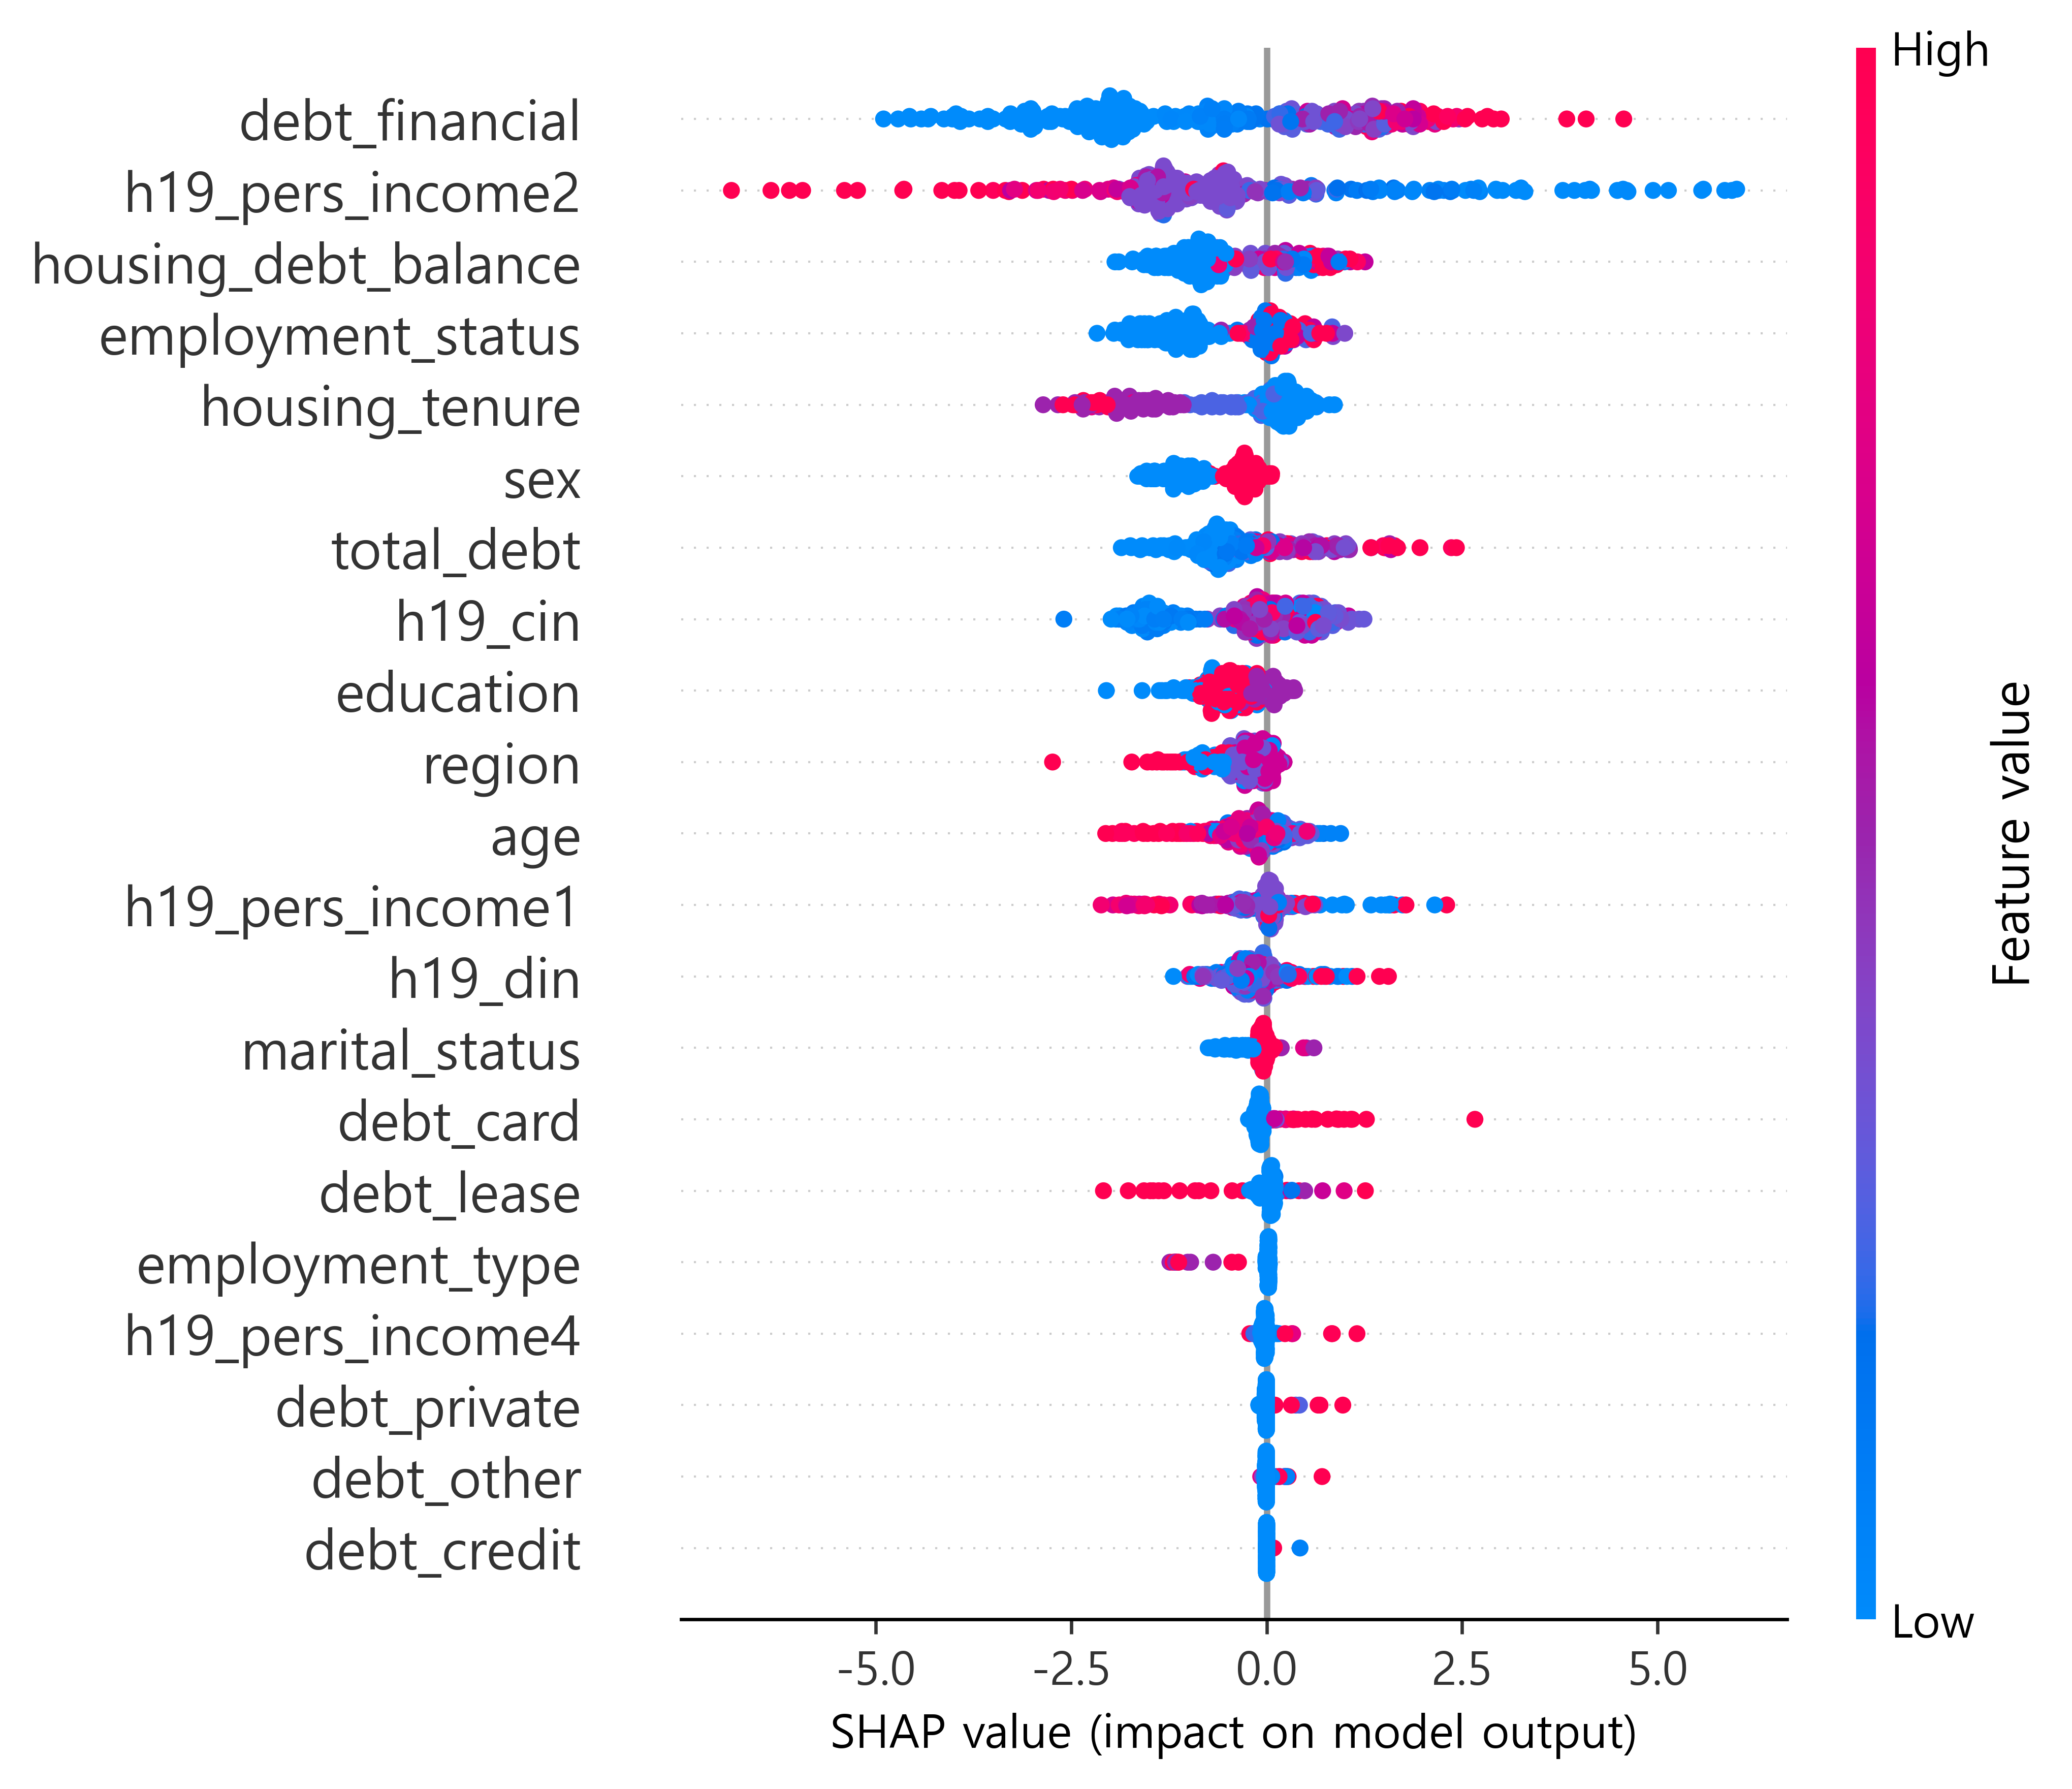

Saved -> outputs/10_shap_summary.png


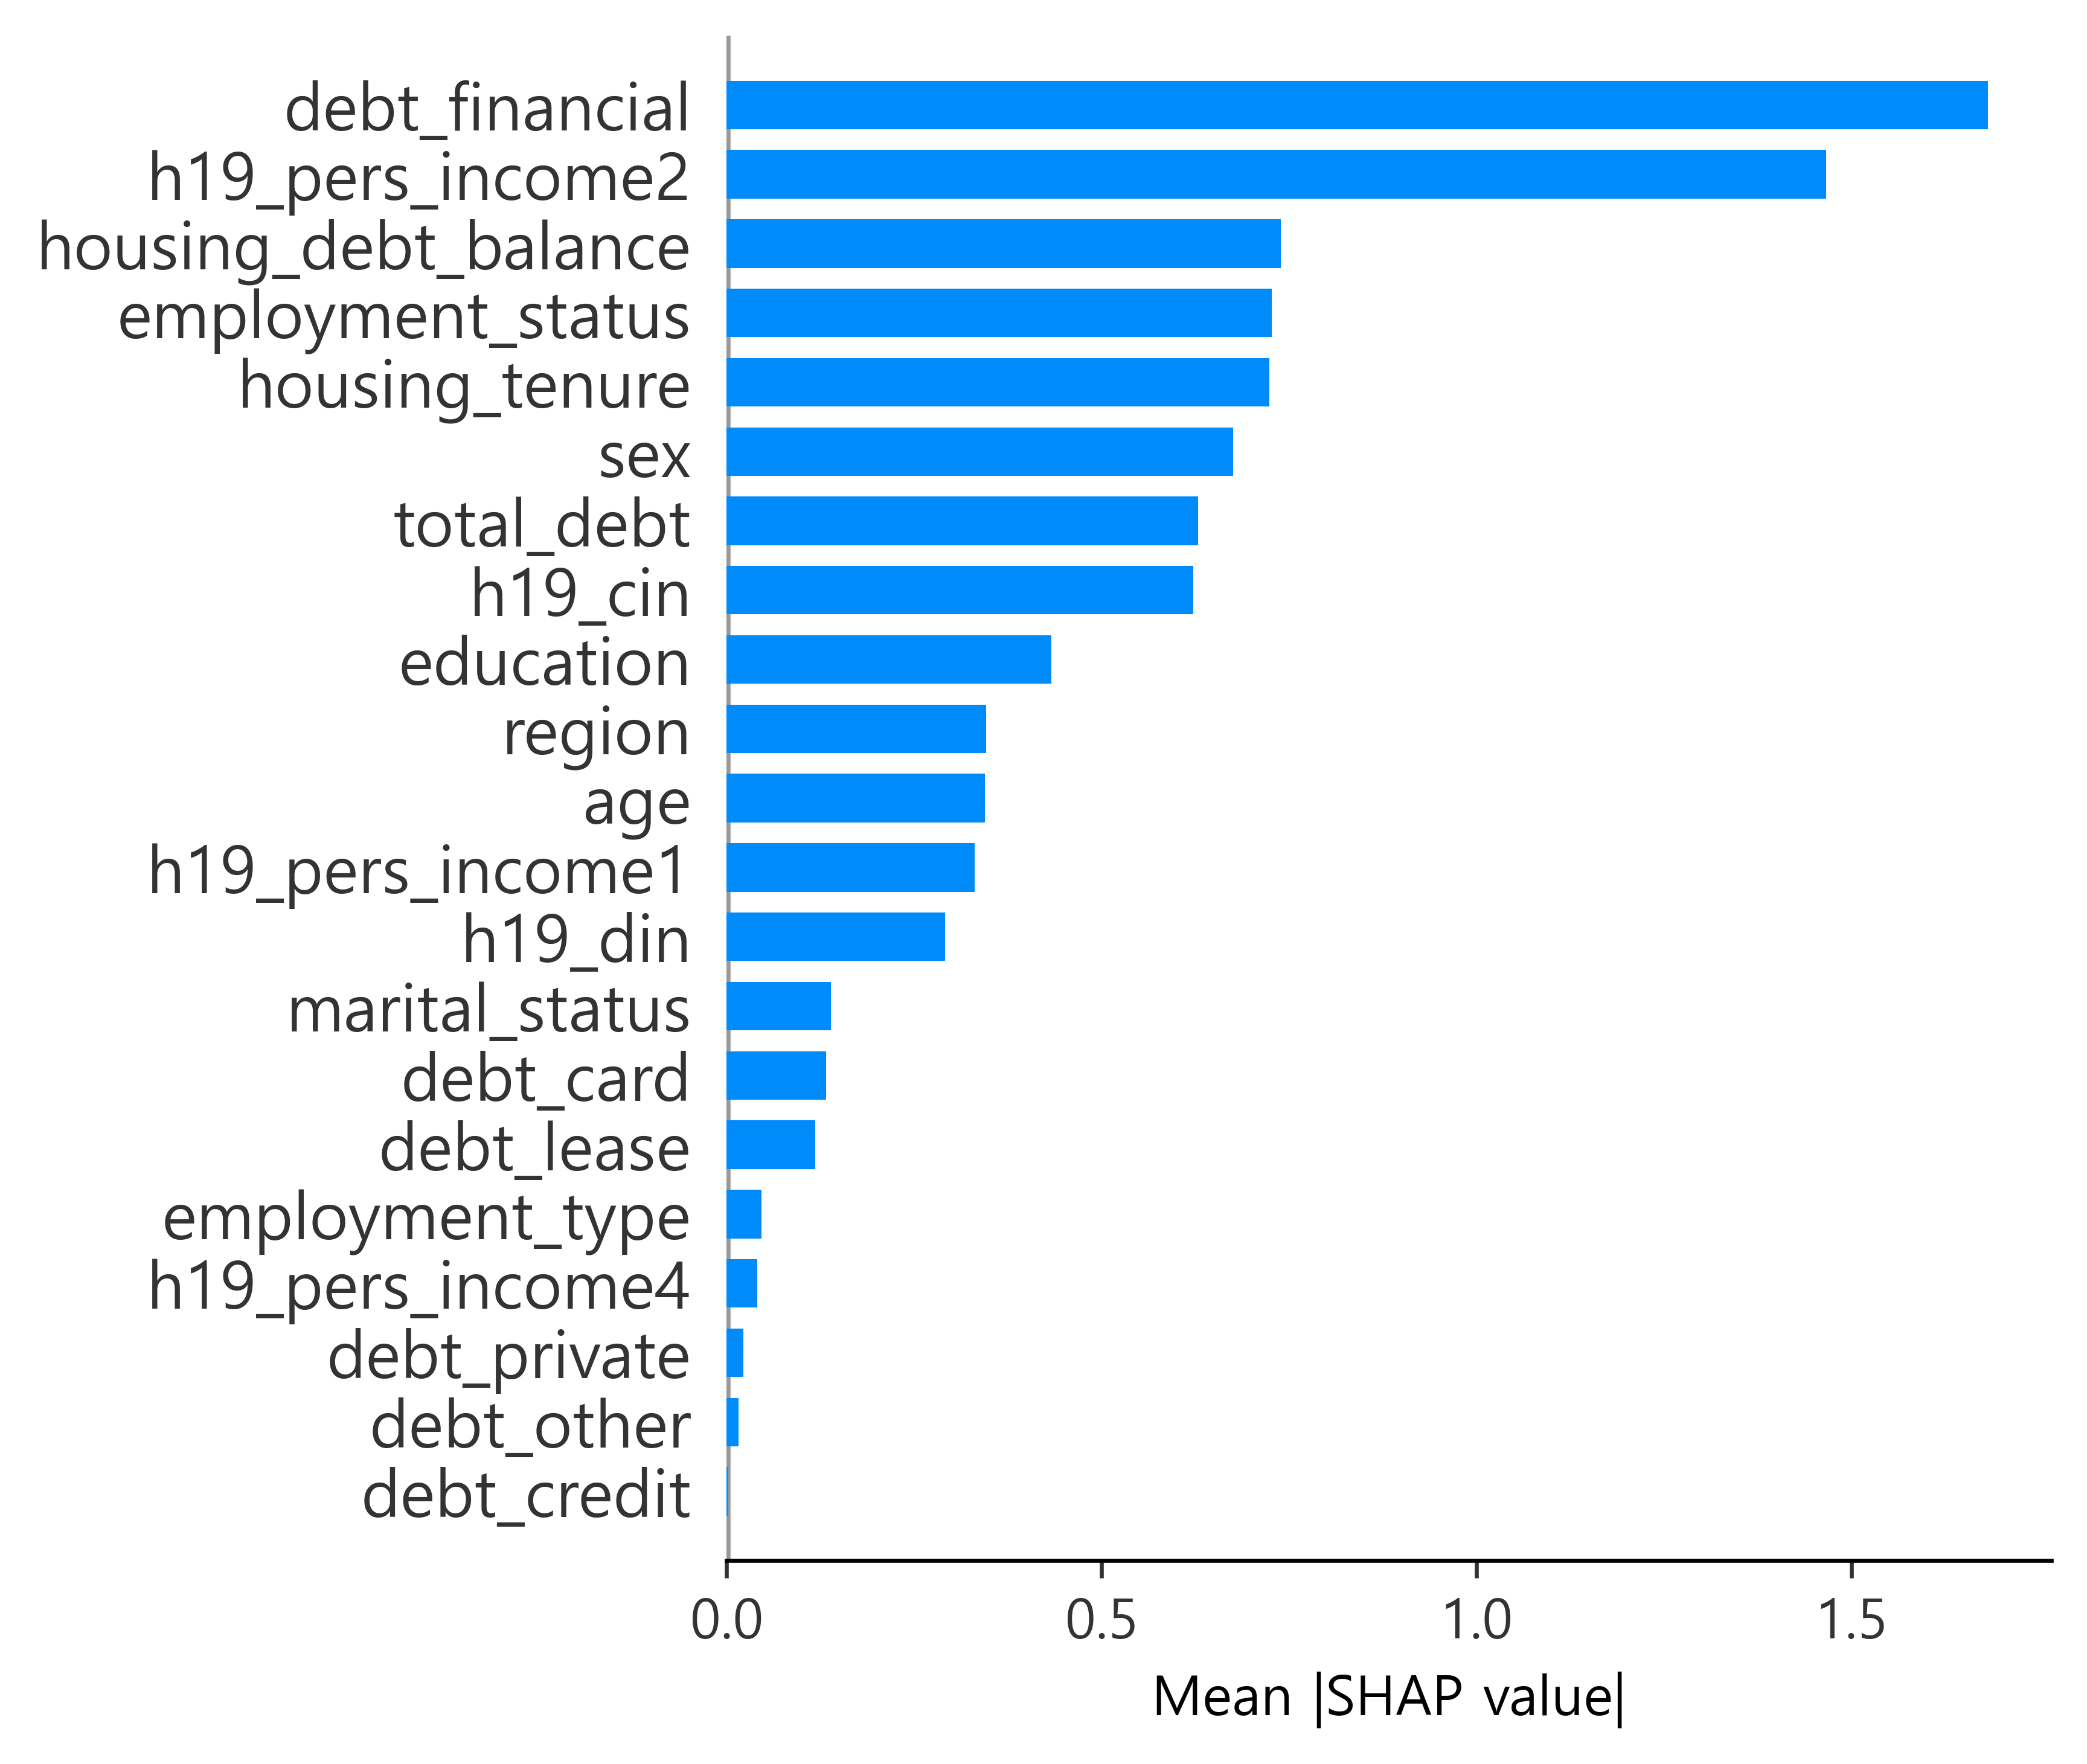

Saved -> outputs/11_shap_bar.png
=== SHAP Feature Importance Ranking ===
             feature  mean_abs_shap  rank
      debt_financial       1.682053     1
    h19_pers_income2       1.466293     2
housing_debt_balance       0.738900     3
   employment_status       0.726961     4
      housing_tenure       0.723215     5
                 sex       0.675200     6
          total_debt       0.628358     7
             h19_cin       0.621893     8
           education       0.432783     9
              region       0.345666    10
                 age       0.344139    11
    h19_pers_income1       0.330358    12
             h19_din       0.290874    13
      marital_status       0.138548    14
           debt_card       0.132125    15
          debt_lease       0.118124    16
     employment_type       0.045943    17
    h19_pers_income4       0.040701    18
        debt_private       0.021909    19
          debt_other       0.015702    20
         debt_credit       0.002182    21

Sa

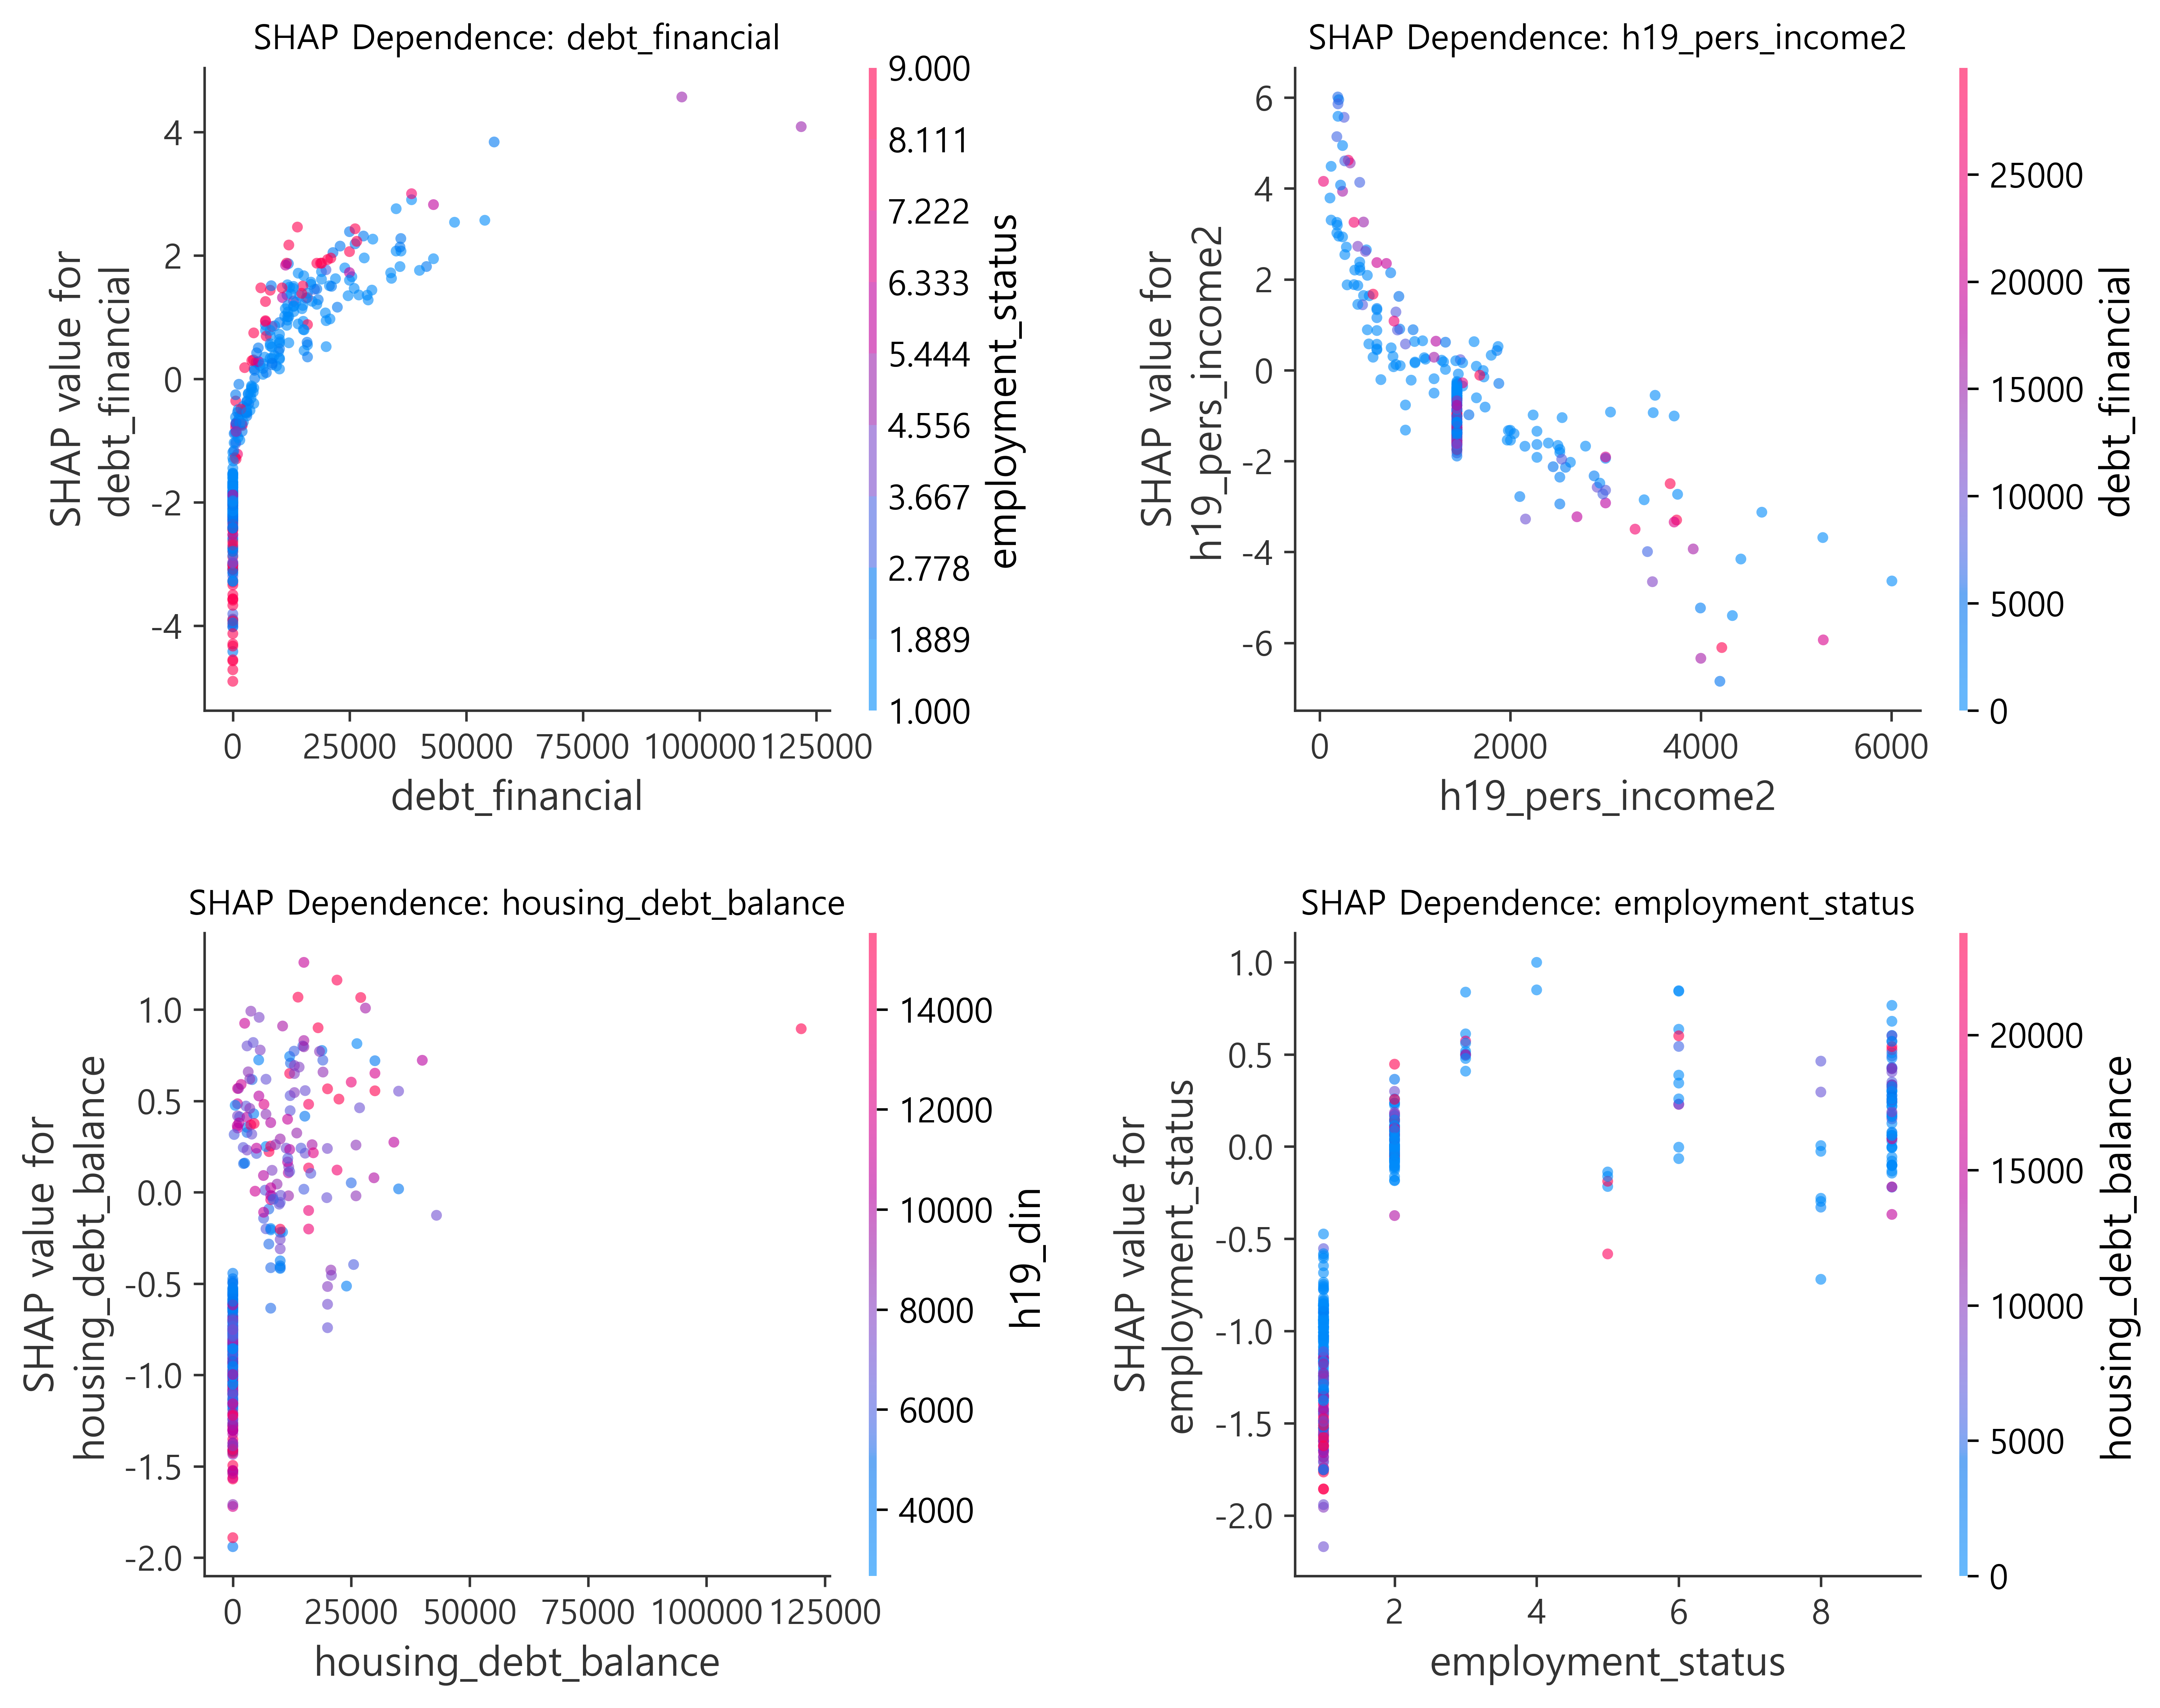

Saved -> outputs/12_shap_dependence.png
Saved temp -> ../outputs/tmp_waterfall_0.png
Saved temp -> ../outputs/tmp_waterfall_1.png
Saved temp -> ../outputs/tmp_waterfall_2.png
Saved -> outputs/13_shap_waterfall_crisis.png


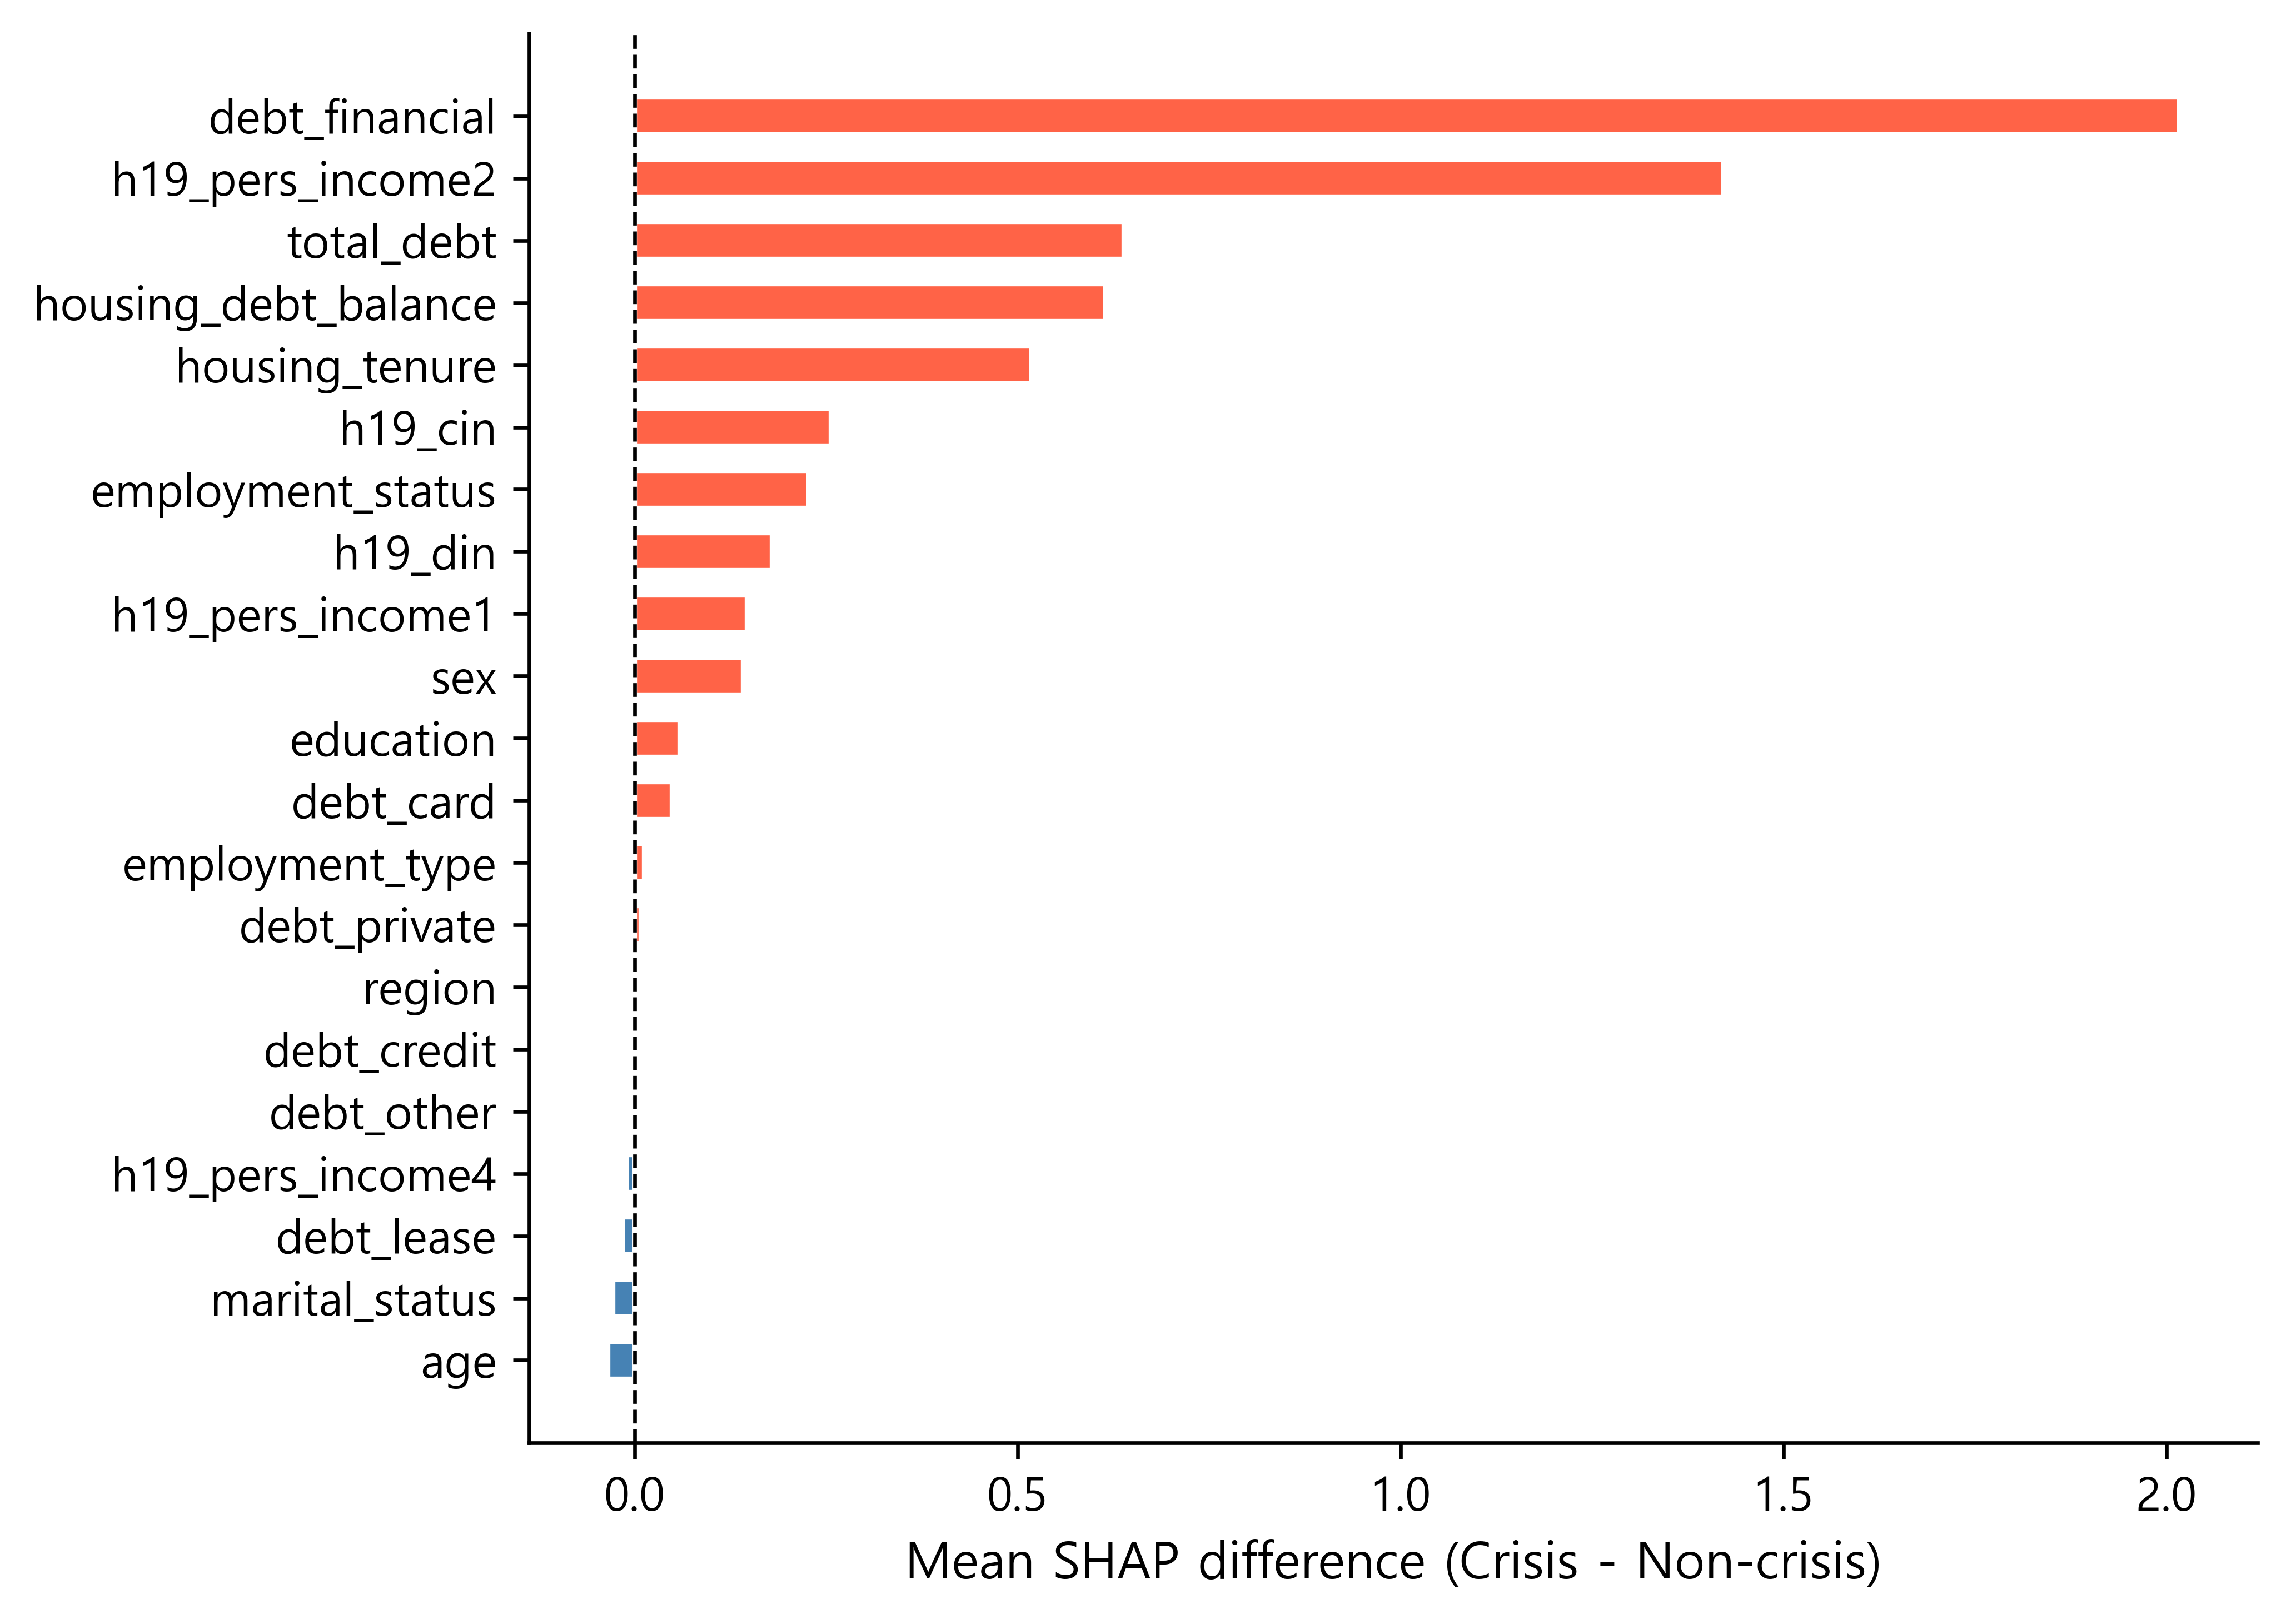

Saved -> outputs/14_shap_group_diff.png


In [2]:
# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import warnings
from PIL import Image
import os

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm = joblib.load('../outputs/model_lgbm.pkl')
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()
X_train = pd.read_csv('../data/X_train_sm.csv')

print(f"X_test shape  : {X_test.shape}")
print(f"X_train shape : {X_train.shape}")


# ─────────────────────────────────────────────
# Cell 3 | Compute SHAP values
# ─────────────────────────────────────────────
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

exp_val = explainer.expected_value
if isinstance(exp_val, (list, np.ndarray)):
    exp_val = float(exp_val[1])

print(f"SHAP values shape : {sv.shape}")
print(f"Expected value    : {exp_val:.4f}")


# ─────────────────────────────────────────────
# Cell 4 | Beeswarm summary plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
shap.summary_plot(sv, X_test, show=False, max_display=21, plot_size=None)
ax = plt.gca()
ax.set_xlabel('SHAP value (impact on model output)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/10_shap_summary.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/10_shap_summary.png")


# ─────────────────────────────────────────────
# Cell 5 | Bar importance plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
shap.summary_plot(sv, X_test, plot_type='bar', show=False, max_display=21, plot_size=None)
ax = plt.gca()
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/11_shap_bar.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/11_shap_bar.png")


# ─────────────────────────────────────────────
# Cell 6 | SHAP importance table
# ─────────────────────────────────────────────
mean_shap = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(sv).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_shap['rank'] = range(1, len(mean_shap) + 1)
print("=== SHAP Feature Importance Ranking ===")
print(mean_shap.to_string(index=False))

mean_shap.to_csv('../outputs/shap_importance.csv', index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/shap_importance.csv")


# ─────────────────────────────────────────────
# Cell 7 | Dependence plots (top 4 features)
# ─────────────────────────────────────────────
top4 = mean_shap['feature'].iloc[:4].tolist()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i in range(len(top4)):
    feat = top4[i]
    shap.dependence_plot(feat, sv, X_test, ax=axes[i], show=False,
                         interaction_index='auto', dot_size=12, alpha=0.6)
    axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=11, pad=6)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/12_shap_dependence.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/12_shap_dependence.png")


# ─────────────────────────────────────────────
# Cell 8 | Waterfall plots — 3 crisis cases (개별 저장 후 가로로 합치기)
# ─────────────────────────────────────────────
X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)
crisis_pos = y_test_r[y_test_r == 1].index.tolist()[:3]

tmp_paths = []
for i, pos in enumerate(crisis_pos):
    shap_obj = shap.Explanation(
        values=sv[pos],
        base_values=exp_val,
        data=X_test_r.iloc[pos].values,
        feature_names=X_test.columns.tolist()
    )
    fig, ax = plt.subplots(figsize=(9, 7))
    plt.sca(ax)
    shap.plots.waterfall(shap_obj, max_display=10, show=False)
    ax.set_title(f'Crisis Case #{i+1}', fontsize=12, pad=8)
    path = f'../outputs/tmp_waterfall_{i}.png'
    plt.savefig(path, dpi=600, bbox_inches='tight', format='png')
    plt.close()
    tmp_paths.append(path)
    print(f"Saved temp -> {path}")

# 가로로 합치기
imgs = [Image.open(p) for p in tmp_paths]
total_w = sum(im.width for im in imgs)
max_h = max(im.height for im in imgs)
combined = Image.new('RGB', (total_w, max_h), (255, 255, 255))
x_offset = 0
for im in imgs:
    combined.paste(im, (x_offset, 0))
    x_offset += im.width

combined.save('../outputs/13_shap_waterfall_crisis.png', dpi=(600, 600))

# 임시파일 삭제
for p in tmp_paths:
    os.remove(p)

print("Saved -> outputs/13_shap_waterfall_crisis.png")


# ─────────────────────────────────────────────
# Cell 9 | Group SHAP difference bar
# ─────────────────────────────────────────────
shap_df = pd.DataFrame(sv, columns=X_test.columns)
shap_df['debt_crisis'] = y_test_r.values

group_shap = shap_df.groupby('debt_crisis').mean().T
group_shap.columns = ['Non-crisis', 'Crisis']
group_shap['diff'] = group_shap['Crisis'] - group_shap['Non-crisis']
group_shap = group_shap.sort_values('diff', ascending=True)

colors = ['tomato' if v > 0 else 'steelblue' for v in group_shap['diff']]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(group_shap.index, group_shap['diff'],
        color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Mean SHAP difference (Crisis - Non-crisis)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/14_shap_group_diff.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/14_shap_group_diff.png")